# Indicator Variables and IF-THEN Logic: Turning Conditions into Constraints

This notebook shows how **indicator variables** let a model "see" when a condition is active so it can enforce IF-THEN rules.

Understanding indicator variables is critical because:
- **Many policies apply only when certain conditions are met** (e.g., "if any AI project is funded"), not all the time.
- **Binary decision variables alone do not track conditions** – they only track individual yes/no choices.
- **Indicator variables act as policy switches**: when they are 1, certain rules turn on.

You will see how to:
- Define indicator variables that turn on when a group of decisions is active.
- Use indicators to trigger follow-on requirements inside the model.
- Validate that the encoded IF-THEN logic behaves as intended.

## Key Concepts

**Decision variables vs indicator variables**
- Decision variables represent concrete choices: select project A, fund project B.
- Indicator variables represent **conditions**: "any AI project selected", "any infrastructure upgrade active".

**How indicators implement IF-THEN logic**
- Step 1: Tie the indicator to the condition (e.g., any chosen AI project sets `y_ai_active = 1`).
- Step 2: Tie the requirement to the indicator (e.g., if `y_ai_active = 1`, then a data governance project must be selected).

**Why they matter**
- Without indicators, conditional policies either apply **always** or **never**, which is almost always wrong.
- With indicators, the model can **switch rules on and off** based on what it decides.

**Critical insight**: Indicators are the bridge between "what the model decided" and "which policies now apply".

## Scenario: AI Projects that Require a Data Governance Project

You are building a project portfolio model for a technology organization.

**Projects**:
- Two AI projects: `AI_Chatbot`, `AI_RiskScoring`.
- One data governance project: `Data_Governance`.
- One ordinary infrastructure project: `Network_Upgrade`.

Each project has a **cost** and an **estimated benefit score**.

**Business policy**:
- "If any AI-related project is funded, a data governance project must also be funded."

**Decisions**:
- `x_AI_Chatbot`, `x_AI_RiskScoring`, `x_Data_Governance`, `x_Network_Upgrade` – binary decision variables: 1 if the project is funded, 0 if not.

**Indicator**:
- `y_AI_active` – 1 if **any** AI project is funded, 0 otherwise.

**Objective**:
- Maximize total benefit subject to a budget and the AI/data governance policy.

You will see how `y_AI_active` connects the AI decisions to the governance requirement.

## Step 1: Install Required Packages

### Setup: Install Required Packages

To run the optimization models in this notebook, we need to install the PuLP library.

**What this code does:** Installs the `pulp` package (for optimization) and supporting libraries used throughout this lesson.

**What to look for in the output:** You should see "Requirement already satisfied" if `pulp` is already installed, or installation messages if it needs to be added.

In [1]:
# Install required packages (needed in Google Colab; can be skipped locally if already installed)
%pip install pulp pandas numpy matplotlib -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

### Setup: Import Libraries

We'll use Python libraries to build our models, summarize results, and create a small visualization.

**What this code does:** Loads `pandas` (for tables), `numpy` (for calculations), `matplotlib` (for a simple chart), and `pulp` (for optimization).

**What to look for in the output:** There is no expected output – successful imports run silently. If you see an error, install the missing package.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpProblem, LpVariable, lpSum, value, LpStatus, PULP_CBC_CMD

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Step 3: Define Project Data

We'll start by setting up a small dataset for the four projects.

**Data columns**:
- `type`: whether the project is AI, governance, or infrastructure.
- `cost`: how much it costs to fund the project.
- `benefit`: a simple benefit score representing impact.

We'll also define:
- A total budget the portfolio must respect.
- The text of the AI/governance policy so you can see how it maps to constraints.

In [3]:
# Project data
projects = pd.DataFrame(
    [
        {"project": "AI_Chatbot", "type": "AI", "cost": 120, "benefit": 220},
        {"project": "AI_RiskScoring", "type": "AI", "cost": 150, "benefit": 260},
        {"project": "Data_Governance", "type": "Governance", "cost": 90, "benefit": 140},
        {"project": "Network_Upgrade", "type": "Infrastructure", "cost": 80, "benefit": 130},
    ]
)

budget = 300  # total budget units
policy_text = "If any AI-related project is funded, a data governance project must also be funded."

print("PROJECT DATA:")
print(projects.to_string(index=False))
print("\nBudget:", budget)
print("Policy:")
print(" ", policy_text)

PROJECT DATA:
        project           type  cost  benefit
     AI_Chatbot             AI   120      220
 AI_RiskScoring             AI   150      260
Data_Governance     Governance    90      140
Network_Upgrade Infrastructure    80      130

Budget: 300
Policy:
  If any AI-related project is funded, a data governance project must also be funded.


## Step 4: Build the Portfolio Model with an Indicator Variable

We now build a project selection model with:

- **Decision variables** `x[p]` for each project `p` (1 if funded, 0 if not).
- **Indicator variable** `y_AI_active` that becomes 1 when **any AI project** is selected.

**Encoding the logic**:
1. Tie the indicator to the AI decisions:
   - `y_AI_active ≥ x[AI_Chatbot]`
   - `y_AI_active ≥ x[AI_RiskScoring]`
   - This ensures `y_AI_active` is 1 if any AI project is 1.
2. Tie the policy requirement to the indicator:
   - `x[Data_Governance] ≥ y_AI_active`
   - If any AI project is funded (`y_AI_active = 1`), data governance must also be 1.

**Objective**:
- Maximize total benefit subject to budget and policy.

**What this code does:**
- Creates the model, decision variables, indicator, objective, budget constraint, and AI/governance logic.
- Solves the model and prints the resulting portfolio.

**What to look for in the output:**
- Which projects are selected.
- Whether any chosen AI project is always accompanied by `Data_Governance`.


In [4]:
# Build the optimization model

model = LpProblem("AI_Portfolio_With_Indicator", LpMaximize)

# Decision variables: x[p] = 1 if project p is funded
x = {
    row["project"]: LpVariable(f"x_{row['project']}", lowBound=0, upBound=1, cat="Binary")
    for _, row in projects.iterrows()
}

# Indicator: y_AI_active = 1 if any AI project is selected
y_AI_active = LpVariable("y_AI_active", lowBound=0, upBound=1, cat="Binary")

# Objective: maximize total benefit
model += lpSum(projects.apply(lambda r: r["benefit"] * x[r["project"]], axis=1)), "Total_Benefit"

# Budget constraint
model += lpSum(projects.apply(lambda r: r["cost"] * x[r["project"]], axis=1)) <= budget, "Budget_Limit"

# Indicator activation: if any AI project is selected, y_AI_active must be 1
ai_projects = projects[projects["type"] == "AI"]["project"].tolist()
for p in ai_projects:
    model += y_AI_active >= x[p], f"AI_indicator_ge_{p}"

# Policy constraint: if any AI is active (y_AI_active = 1), Data_Governance must be funded
model += x["Data_Governance"] >= y_AI_active, "AI_requires_Data_Governance"

# Solve the model
solver = PULP_CBC_CMD(msg=False)
model.solve(solver)

status = LpStatus[model.status]
print("Model status:", status)

# Collect results
solution = []
for _, row in projects.iterrows():
    p = row["project"]
    solution.append(
        {
            "project": p,
            "type": row["type"],
            "cost": row["cost"],
            "benefit": row["benefit"],
            "selected (x)": int(x[p].value()),
        }
    )

solution_df = pd.DataFrame(solution)
solution_df["cost_if_selected"] = solution_df["selected (x)"] * solution_df["cost"]
solution_df["benefit_if_selected"] = solution_df["selected (x)"] * solution_df["benefit"]

print("\nOPTIMAL PORTFOLIO:")
print(solution_df.to_string(index=False))
print("\nTotal cost:", int(solution_df["cost_if_selected"].sum()))
print("Total benefit:", int(solution_df["benefit_if_selected"].sum()))
print("Indicator y_AI_active:", int(y_AI_active.value()))

Model status: Optimal

OPTIMAL PORTFOLIO:
        project           type  cost  benefit  selected (x)  cost_if_selected  benefit_if_selected
     AI_Chatbot             AI   120      220             1               120                  220
 AI_RiskScoring             AI   150      260             0                 0                    0
Data_Governance     Governance    90      140             1                90                  140
Network_Upgrade Infrastructure    80      130             1                80                  130

Total cost: 290
Total benefit: 490
Indicator y_AI_active: 1


## Step 5: Validate the IF-THEN Logic Programmatically

We now **check in code** that the policy has truly been enforced:

> If any AI-related project is funded, a data governance project must also be funded.

**What this code does:**
- Counts how many AI projects are selected.
- Asserts that whenever at least one AI project is selected, `Data_Governance` is also selected.
- Provides a clear message if the constraint is ever violated.

**What to look for in the output:**
- A confirmation message that the validation check passed.
- If the assertion fails, it means the model solution does not match the policy – which should not happen if the constraints are correct.

In [5]:
# Validation: if any AI project is funded, Data_Governance must be funded

selected_ai = solution_df[(solution_df["type"] == "AI") & (solution_df["selected (x)"] == 1)]
ai_count = selected_ai.shape[0]

data_gov_selected = int(solution_df[solution_df["project"] == "Data_Governance"]["selected (x)"].iloc[0])

print(f"Number of AI projects selected: {ai_count}")
print(f"Data_Governance selected (1=yes, 0=no): {data_gov_selected}")
print("Indicator y_AI_active:", int(y_AI_active.value()))

if ai_count > 0:
    assert data_gov_selected == 1, (
        "Policy violation: At least one AI project is funded but Data_Governance is not funded."
    )
    assert int(y_AI_active.value()) == 1, (
        "Indicator inconsistency: AI projects are selected but y_AI_active is not 1."
    )
    print("\nValidation passed: AI projects are funded AND Data_Governance is funded, with y_AI_active = 1.")
else:
    assert int(y_AI_active.value()) in (0, 1), "Indicator y_AI_active should be binary."
    if int(y_AI_active.value()) == 0:
        print("\nValidation: No AI projects funded, y_AI_active = 0, and Data_Governance may or may not be funded.")
    else:
        print("\nNote: No AI projects funded, but y_AI_active = 1. This is allowed mathematically but unusual.")

Number of AI projects selected: 1
Data_Governance selected (1=yes, 0=no): 1
Indicator y_AI_active: 1

Validation passed: AI projects are funded AND Data_Governance is funded, with y_AI_active = 1.


## Step 6: Visual Summary – Which Projects Are Selected?

A simple bar chart can help quickly see which projects are funded and how they relate to the policy.

**What this code does:**
- Plots a bar (0 or 1) for each project’s selection decision.
- Uses clear labels and a single figure for readability.

**What to look for in the output:**
- Which bars are at 1 (funded) vs 0 (not funded).
- Whether funded AI projects appear together with a funded `Data_Governance` bar.

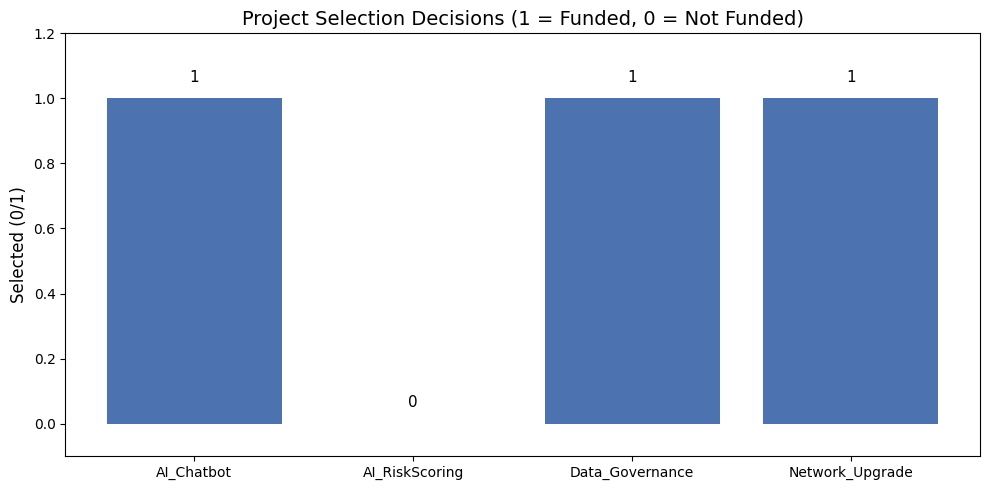

In [6]:
# Simple bar chart of project selection decisions

fig, ax = plt.subplots()

ax.bar(solution_df["project"], solution_df["selected (x)"], color="#4C72B0")
ax.set_title("Project Selection Decisions (1 = Funded, 0 = Not Funded)")
ax.set_ylabel("Selected (0/1)")
ax.set_ylim(-0.1, 1.2)

for idx, row in solution_df.iterrows():
    ax.text(idx, row["selected (x)"] + 0.05, str(int(row["selected (x)"])), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## Conclusion: Indicators as Policy Switches

In this notebook, you saw that:

- Decision variables alone cannot represent the idea that "any AI project is active" – you needed an **indicator** `y_AI_active`.
- By tying the indicator to AI project decisions and then tying the data governance requirement to the indicator, you implemented a clear IF-THEN rule.
- Programmatic validation checks confirmed that whenever AI projects are funded, `Data_Governance` is also funded.
- The indicator behaves exactly like a **policy switch**: when it is 1, certain rules (constraints) turn on; when it is 0, those rules stay off.

This pattern – condition → indicator → rule – is the backbone of many logical constraints you will build in real models.